# AML Graph Intelligence Engine — EDA From Scratch (v3, fault-proof join)
### Track 3 — Network & Graph Intelligence



## Setup

In [3]:
import os
import glob
import json
from collections import Counter
import xml.etree.ElementTree as ET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## Step 1 — Get the data into Colab

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/STUDENT_DATASET"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Confirm files are present, then load everything

In [5]:
FILES = {
    "accounts": "accounts.csv",
    "transactions": "transactions.csv",
    "graph_edges": "graph_edges.csv",
    "ml_features": "ml_features.csv",
}
paths = {key: os.path.join(DATA_DIR, fname) for key, fname in FILES.items()}
paths["reports"] = os.path.join(DATA_DIR, "reports")

for key, p in paths.items():
    exists = os.path.isfile(p) if key != "reports" else os.path.isdir(p)
    print(f"  [{'OK' if exists else 'MISSING'}] {p}")

df_accounts = pd.read_csv(paths["accounts"])
df_txn      = pd.read_csv(paths["transactions"])
df_edges    = pd.read_csv(paths["graph_edges"])
df_features = pd.read_csv(paths["ml_features"])

print()
print(f"accounts.csv      -> {df_accounts.shape[0]:,} rows x {df_accounts.shape[1]} cols")
print(f"transactions.csv  -> {df_txn.shape[0]:,} rows x {df_txn.shape[1]} cols")
print(f"graph_edges.csv   -> {df_edges.shape[0]:,} rows x {df_edges.shape[1]} cols")
print(f"ml_features.csv   -> {df_features.shape[0]:,} rows x {df_features.shape[1]} cols")


  [OK] /content/drive/MyDrive/STUDENT_DATASET/accounts.csv
  [OK] /content/drive/MyDrive/STUDENT_DATASET/transactions.csv
  [OK] /content/drive/MyDrive/STUDENT_DATASET/graph_edges.csv
  [OK] /content/drive/MyDrive/STUDENT_DATASET/ml_features.csv
  [OK] /content/drive/MyDrive/STUDENT_DATASET/reports

accounts.csv      -> 65,339 rows x 13 cols
transactions.csv  -> 100,222 rows x 55 cols
graph_edges.csv   -> 100,222 rows x 6 cols
ml_features.csv   -> 100,222 rows x 35 cols


## Step 3 — Lock in the confirmed schema as constants

In [6]:
SENDER_COL      = "Sender_account"
RECEIVER_COL    = "Receiver_account"
AMOUNT_COL      = "amount_local_npr"
AMOUNT_FACE_COL = "Amount"
DATE_COL        = "Date"
TIME_COL        = "Time"
ACCOUNT_ID_COL  = "account_id"
LABEL_COL       = "is_suspicious_tx"

for col, df_, name in [
    (SENDER_COL, df_txn, "transactions.csv"), (RECEIVER_COL, df_txn, "transactions.csv"),
    (AMOUNT_COL, df_txn, "transactions.csv"), (DATE_COL, df_txn, "transactions.csv"),
    (TIME_COL, df_txn, "transactions.csv"), (ACCOUNT_ID_COL, df_accounts, "accounts.csv"),
    (LABEL_COL, df_features, "ml_features.csv"),
]:
    ok = col in df_.columns
    print(f"  [{'OK' if ok else 'MISSING'}] '{col}' in {name}")


  [OK] 'Sender_account' in transactions.csv
  [OK] 'Receiver_account' in transactions.csv
  [OK] 'amount_local_npr' in transactions.csv
  [OK] 'Date' in transactions.csv
  [OK] 'Time' in transactions.csv
  [OK] 'account_id' in accounts.csv
  [OK] 'is_suspicious_tx' in ml_features.csv


---
## EDA Requirement 1 — Dataset overview

In [7]:
def show_overview(df, name):
    print("=" * 65)
    print(name)
    print("=" * 65)
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print()
    print(df.dtypes)
    print()
    display(df.head(3))
    print()

for name, df_ in [("accounts.csv", df_accounts), ("transactions.csv", df_txn),
                   ("graph_edges.csv", df_edges), ("ml_features.csv", df_features)]:
    show_overview(df_, name)


accounts.csv
Shape: 65,339 rows x 13 columns
Memory: 32.9 MB

account_id         int64
account_number    object
institution       object
branch            object
acct_type         object
risk_grade        object
is_person           bool
name              object
tax_number         int64
pep_flag           int64
sanctions_hit      int64
city              object
opened            object
dtype: object



,account_id,account_number,institution,branch,acct_type,risk_grade,is_person,name,tax_number,pep_flag,sanctions_hit,city,opened
0,8724731955,NP00000000000237070764,HBL,BR_002,FIXED,RISK-LOW,True,John Stephens,418908707,0,0,Hetauda,2015-12-27
1,1491989064,NP00000000004025829570,NCC,BR_010,SAVINGS,RISK-LOW,True,Mary Smith,432993733,0,0,Ghorahi,2022-12-19
2,287305149,NP00000000001789345609,CBL,BR_001,CURRENT,RISK-MED,True,Ruth Clements,337939969,0,0,Birgunj,2019-04-12



transactions.csv
Shape: 100,222 rows x 55 columns
Memory: 143.4 MB

row_index                      int64
Date                          object
Time                          object
Sender_account                 int64
Receiver_account               int64
Amount                       float64
Payment_currency              object
Received_currency             object
Sender_bank_location          object
Receiver_bank_location        object
Payment_type                  object
transmode_code                object
fx_rate_to_npr               float64
amount_local_npr             float64
sender_country_risk          float64
receiver_country_risk        float64
cross_border_flag              int64
currency_mismatch              int64
sender_institution            object
sender_branch                 object
sender_account_number         object
sender_account_type           object
sender_risk_grade             object
sender_opened                 object
sender_is_person               int64
sender

,row_index,Date,Time,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,transmode_code,fx_rate_to_npr,amount_local_npr,sender_country_risk,receiver_country_risk,cross_border_flag,currency_mismatch,sender_institution,sender_branch,sender_account_number,sender_account_type,sender_risk_grade,sender_opened,sender_is_person,sender_pep,sender_sanctions,sender_city,sender_account_age_days,receiver_institution,receiver_branch,receiver_account_number,receiver_account_type,receiver_pep,receiver_sanctions,receiver_account_age_days,date_transaction,hour_of_day,day_of_week,is_weekend,month,log_amount,above_1M_NPR,above_10M_NPR,velocity_sum_10tx,tx_count_10,tx_count_30,amount_zscore,transmode_A,transmode_B,transmode_E,transmode_F,transmode_J,transmode_P,transmode_Z
0,0,2022-10-07,10:35:19,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,A,205.65,300074.20,0.2,0.2,0,0,HBL,BR_002,NP00000000000237070764,FIXED,RISK-LOW,2015-12-27,1,0,0,Hetauda,3822,CITIZENS,BR_006,NP00000000000570733497,NOSTRO,0,0,1077,2022-10-07 10:35:19,10,4,0,10,12.611788,0,0,300074.20,1.0,1.0,-0.293518,1,0,0,0,0,0,0
1,1,2022-10-07,10:35:20,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,F,205.65,1237938.97,0.2,1.0,1,1,NCC,BR_010,NP00000000004025829570,SAVINGS,RISK-LOW,2022-12-19,1,0,0,Ghorahi,1273,ADBL,BR_011,NP00000000000431981631,CURRENT,0,0,1028,2022-10-07 10:35:20,10,4,0,10,14.028959,1,0,1237938.97,1.0,1.0,-0.106146,0,0,0,1,0,0,0
2,2,2022-10-07,10:35:20,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,E,205.65,2946643.69,0.2,0.2,0,0,CBL,BR_001,NP00000000001789345609,CURRENT,RISK-MED,2019-04-12,1,0,0,Birgunj,2620,MBL,BR_037,NP00000000001227810065,NOSTRO,0,0,5051,2022-10-07 10:35:20,10,4,0,10,14.896178,1,0,2946643.69,1.0,1.0,0.235230,0,0,1,0,0,0,0



graph_edges.csv
Shape: 100,222 rows x 6 columns
Memory: 14.8 MB

row_index             int64
Sender_account        int64
Receiver_account      int64
amount_local_npr    float64
Date                 object
Time                 object
dtype: object



,row_index,Sender_account,Receiver_account,amount_local_npr,Date,Time
0,0,8724731955,2769355426,300074.20,2022-10-07,10:35:19
1,1,1491989064,8401255335,1237938.97,2022-10-07,10:35:20
2,2,287305149,4404767002,2946643.69,2022-10-07,10:35:20



ml_features.csv
Shape: 100,222 rows x 35 columns
Memory: 38.1 MB

Date                          object
Time                          object
Sender_account                 int64
Receiver_account               int64
amount_local_npr             float64
log_amount                   float64
amount_zscore                float64
above_1M_NPR                   int64
above_10M_NPR                  int64
hour_of_day                    int64
day_of_week                    int64
is_weekend                     int64
month                          int64
sender_country_risk          float64
receiver_country_risk        float64
cross_border_flag              int64
currency_mismatch              int64
velocity_sum_10tx            float64
tx_count_10                  float64
tx_count_30                  float64
sender_account_age_days        int64
receiver_account_age_days      int64
sender_is_person               int64
sender_pep                     int64
sender_sanctions               int64
receiver

,Date,Time,Sender_account,Receiver_account,amount_local_npr,log_amount,amount_zscore,above_1M_NPR,above_10M_NPR,hour_of_day,day_of_week,is_weekend,month,sender_country_risk,receiver_country_risk,cross_border_flag,currency_mismatch,velocity_sum_10tx,tx_count_10,tx_count_30,sender_account_age_days,receiver_account_age_days,sender_is_person,sender_pep,sender_sanctions,receiver_pep,receiver_sanctions,transmode_A,transmode_B,transmode_E,transmode_F,transmode_J,transmode_P,transmode_Z,is_suspicious_tx
0,2022-10-07,10:35:19,8724731955,2769355426,300074.20,12.611788,-0.293518,0,0,10,4,0,10,0.2,0.2,0,0,300074.20,1.0,1.0,3822,1077,1,0,0,0,0,1,0,0,0,0,0,0,0
1,2022-10-07,10:35:20,1491989064,8401255335,1237938.97,14.028959,-0.106146,1,0,10,4,0,10,0.2,1.0,1,1,1237938.97,1.0,1.0,1273,1028,1,0,0,0,0,0,0,0,1,0,0,0,0
2,2022-10-07,10:35:20,287305149,4404767002,2946643.69,14.896178,0.235230,1,0,10,4,0,10,0.2,0.2,0,0,2946643.69,1.0,1.0,2620,5051,1,0,0,0,0,0,0,1,0,0,0,0,0


---
## EDA Requirement 2 — Missing value analysis

In [8]:
def missing_report(df, name):
    n = df.isnull().sum()
    pct = (n / len(df) * 100).round(2)
    out = pd.DataFrame({"missing_count": n, "missing_pct": pct})
    out = out[out["missing_count"] > 0].sort_values("missing_pct", ascending=False)
    print(f"--- {name} ---")
    print(out if len(out) else "No missing values in any column.")
    print()
    return out

missing_summary = {}
for name, df_ in [("accounts.csv", df_accounts), ("transactions.csv", df_txn),
                   ("graph_edges.csv", df_edges), ("ml_features.csv", df_features)]:
    missing_summary[name] = missing_report(df_, name)


--- accounts.csv ---
No missing values in any column.

--- transactions.csv ---
No missing values in any column.

--- graph_edges.csv ---
No missing values in any column.

--- ml_features.csv ---
No missing values in any column.



In [9]:
worst_file = max(missing_summary, key=lambda k: missing_summary[k]["missing_pct"].max() if len(missing_summary[k]) else 0)
worst_df = missing_summary[worst_file]

if len(worst_df) > 0:
    plt.figure(figsize=(9, max(3, 0.4 * len(worst_df))))
    sns.barplot(x=worst_df["missing_pct"], y=worst_df.index, color="#c0392b")
    plt.xlabel("% missing")
    plt.title(f"Missing values by column — {worst_file}")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found anywhere — nothing to plot.")


No missing values found anywhere — nothing to plot.


---
## EDA Requirement 3 — Data quality issues identified

In [10]:
print("DATA QUALITY CHECKS")
print("=" * 55)

self_loops = (df_txn[SENDER_COL] == df_txn[RECEIVER_COL]).sum()
print(f"Self-loop transactions: {self_loops:,} ({self_loops/len(df_txn):.3%})")

non_pos = (df_txn[AMOUNT_COL] <= 0).sum()
print(f"Non-positive amounts ({AMOUNT_COL}): {non_pos:,} ({non_pos/len(df_txn):.3%})")
print(f"Amount range: min={df_txn[AMOUNT_COL].min():,.2f}  max={df_txn[AMOUNT_COL].max():,.2f}")

dup_count = df_txn.duplicated().sum()
print(f"Fully duplicated transaction rows: {dup_count:,} ({dup_count/len(df_txn):.3%})")

known = set(df_accounts[ACCOUNT_ID_COL].astype(str))
seen = set(df_txn[SENDER_COL].astype(str)) | set(df_txn[RECEIVER_COL].astype(str))
unknown = seen - known
print(f"Accounts seen in transactions but missing from accounts.csv: {len(unknown):,} of {len(seen):,}")


DATA QUALITY CHECKS
Self-loop transactions: 0 (0.000%)
Non-positive amounts (amount_local_npr): 0 (0.000%)
Amount range: min=3.74  max=552,796,380.22
Fully duplicated transaction rows: 0 (0.000%)
Accounts seen in transactions but missing from accounts.csv: 0 of 65,339


In [ ]:
df_txn["combined_timestamp"] = pd.to_datetime(
    df_txn[DATE_COL].astype(str) + " " + df_txn[TIME_COL].astype(str), errors="coerce"
)
bad_ts = df_txn["combined_timestamp"].isnull().sum()
print(f"Combined timestamp built from {DATE_COL} + {TIME_COL}. Unparseable rows: {bad_ts:,}")
print(f"Range: {df_txn['combined_timestamp'].min()} to {df_txn['combined_timestamp'].max()}")

if "date_transaction" in df_txn.columns:
    candidate = pd.to_datetime(df_txn["date_transaction"], errors="coerce")
    match_rate = (candidate.dt.date == df_txn["combined_timestamp"].dt.date).mean()
    print(f"\n'date_transaction' matches our combined date on {match_rate:.1%} of rows.")


Combined timestamp built from Date + Time. Unparseable rows: 0
Range: 2022-10-07 10:35:19 to 2022-11-06 21:04:35

'date_transaction' matches our combined date on 100.0% of rows.


---
## EDA Requirement 4 — Feature distributions

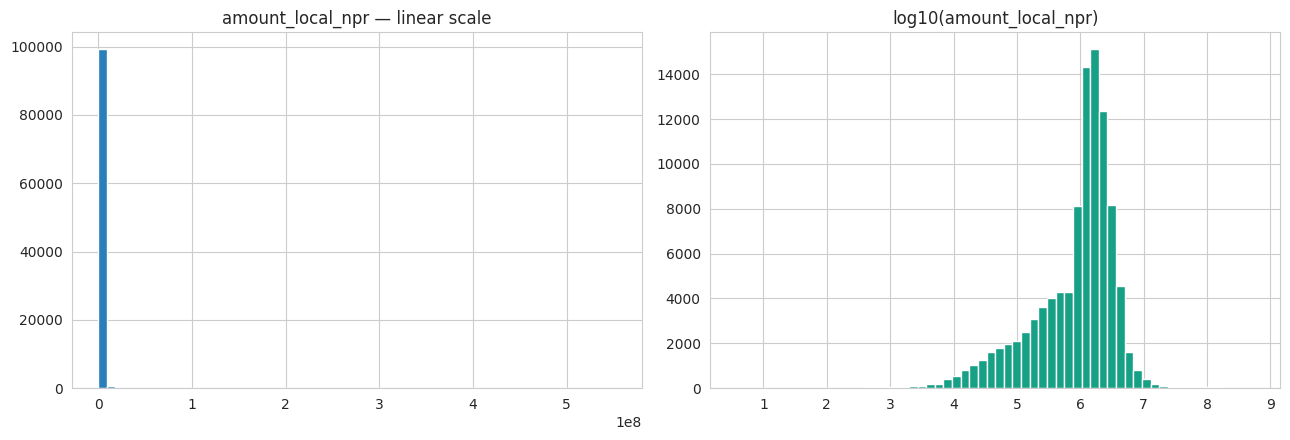

Mean: 1,769,234.80  |  Median: 1,238,979.56  |  Mean is 1.4x median


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df_txn[AMOUNT_COL], bins=60, color="#2980b9")
axes[0].set_title(f"{AMOUNT_COL} — linear scale")

positive_amounts = df_txn[df_txn[AMOUNT_COL] > 0][AMOUNT_COL]
axes[1].hist(np.log10(positive_amounts), bins=60, color="#16a085")
axes[1].set_title(f"log10({AMOUNT_COL})")
plt.tight_layout()
plt.show()

mean_amt, median_amt = df_txn[AMOUNT_COL].mean(), df_txn[AMOUNT_COL].median()
print(f"Mean: {mean_amt:,.2f}  |  Median: {median_amt:,.2f}  |  Mean is {mean_amt/median_amt:.1f}x median")


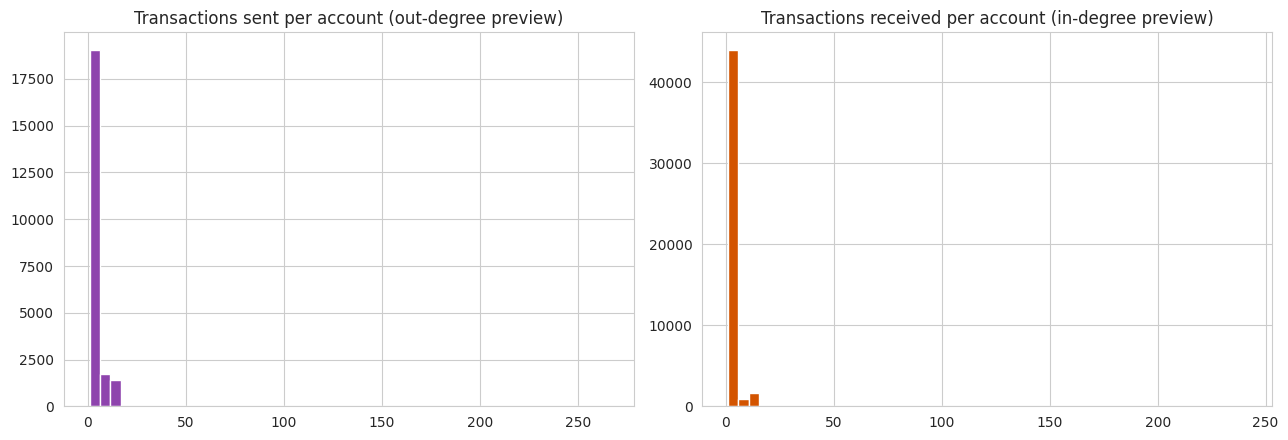

Most active sender: 265 transactions sent by one account
Most active receiver: 241 transactions received by one account


In [12]:
out_counts = df_txn[SENDER_COL].value_counts()
in_counts  = df_txn[RECEIVER_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(out_counts, bins=50, color="#8e44ad")
axes[0].set_title("Transactions sent per account (out-degree preview)")
axes[1].hist(in_counts, bins=50, color="#d35400")
axes[1].set_title("Transactions received per account (in-degree preview)")
plt.tight_layout()
plt.show()

print(f"Most active sender: {out_counts.max():,} transactions sent by one account")
print(f"Most active receiver: {in_counts.max():,} transactions received by one account")


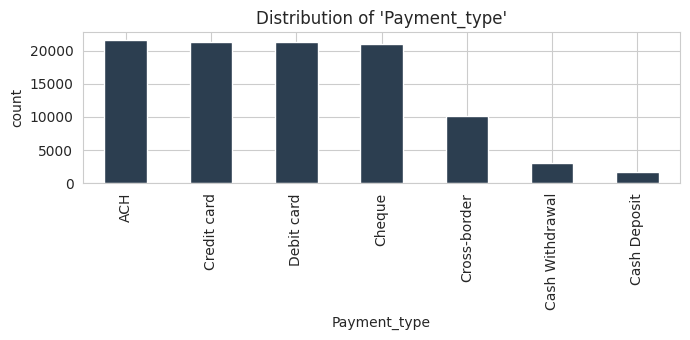

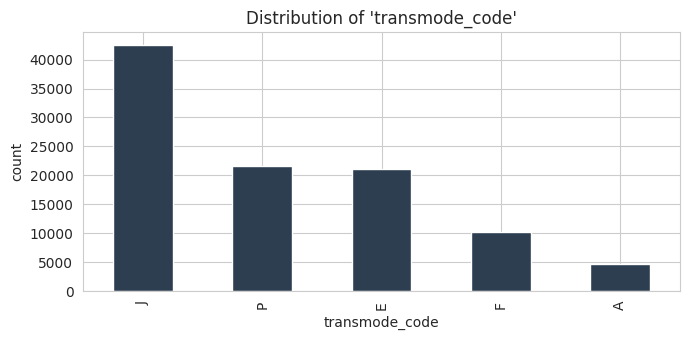

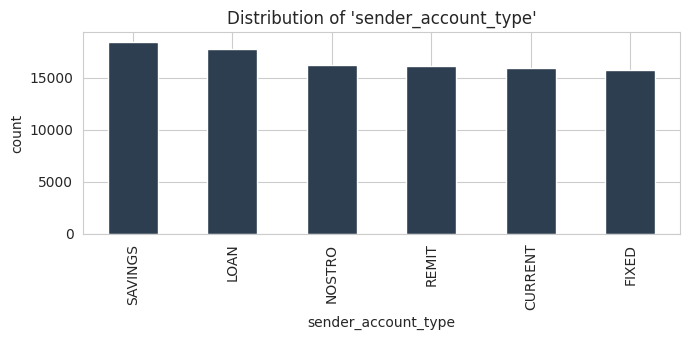

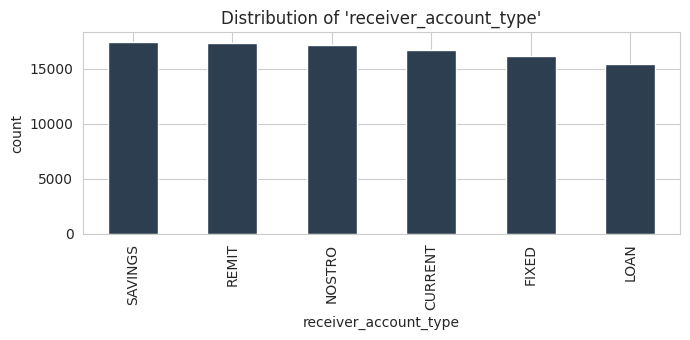

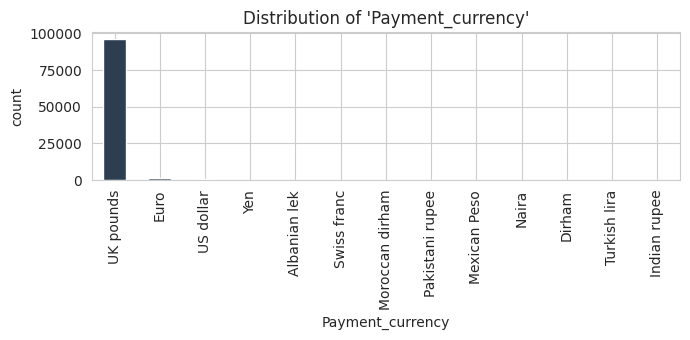

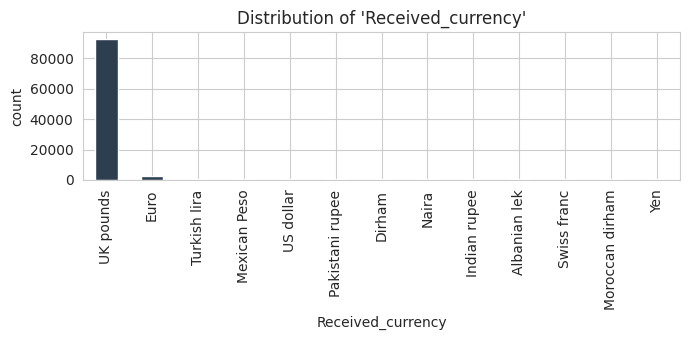

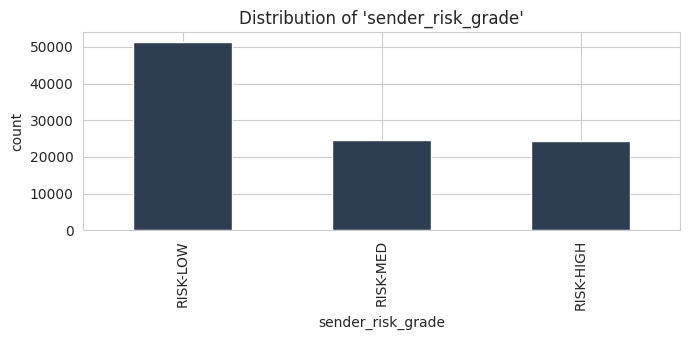

In [13]:
categorical_candidates = ["Payment_type", "transmode_code", "sender_account_type",
                           "receiver_account_type", "Payment_currency", "Received_currency",
                           "sender_risk_grade"]
categorical_candidates = [c for c in categorical_candidates if c in df_txn.columns]

for c in categorical_candidates:
    plt.figure(figsize=(7, 3.5))
    df_txn[c].value_counts().plot(kind="bar", color="#2c3e50")
    plt.title(f"Distribution of '{c}'")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


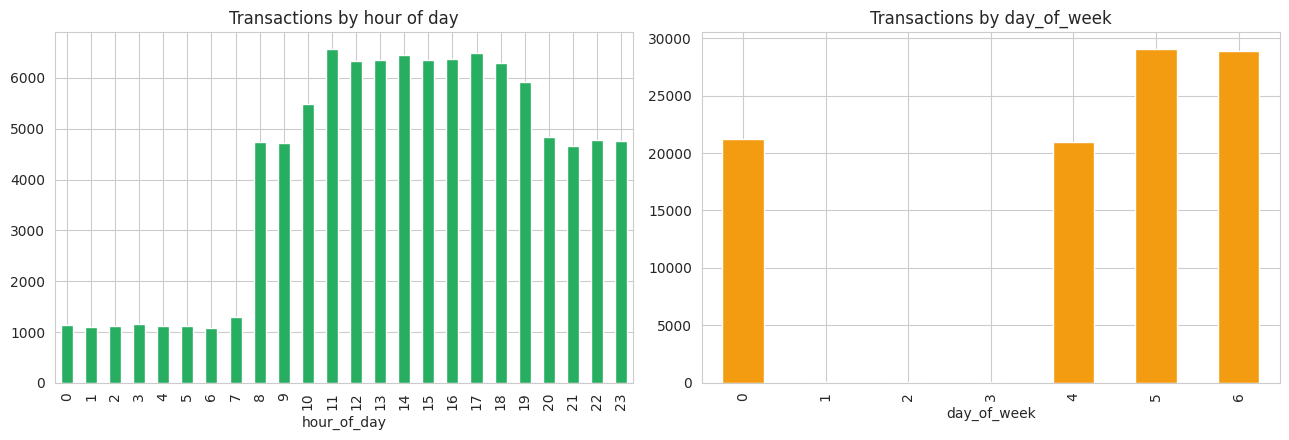

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if "hour_of_day" in df_txn.columns:
    df_txn["hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#27ae60")
    axes[0].set_title("Transactions by hour of day")
if "day_of_week" in df_txn.columns:
    df_txn["day_of_week"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#f39c12")
    axes[1].set_title("Transactions by day_of_week")
plt.tight_layout()
plt.show()


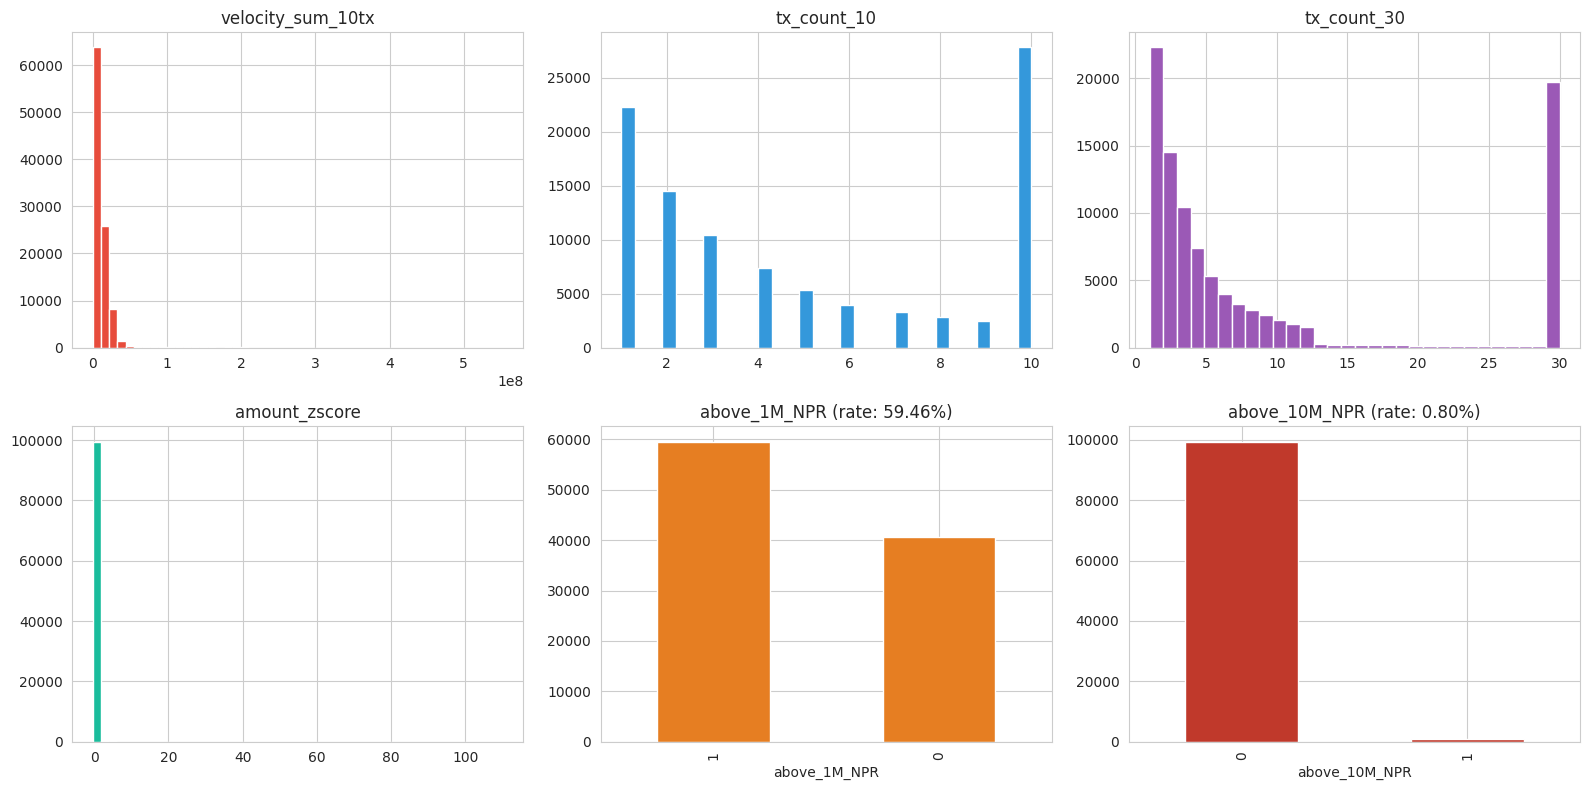

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

if "velocity_sum_10tx" in df_txn.columns:
    axes[0,0].hist(df_txn["velocity_sum_10tx"], bins=50, color="#e74c3c")
    axes[0,0].set_title("velocity_sum_10tx")
if "tx_count_10" in df_txn.columns:
    axes[0,1].hist(df_txn["tx_count_10"], bins=30, color="#3498db")
    axes[0,1].set_title("tx_count_10")
if "tx_count_30" in df_txn.columns:
    axes[0,2].hist(df_txn["tx_count_30"], bins=30, color="#9b59b6")
    axes[0,2].set_title("tx_count_30")
if "amount_zscore" in df_txn.columns:
    axes[1,0].hist(df_txn["amount_zscore"], bins=50, color="#1abc9c")
    axes[1,0].set_title("amount_zscore")
if "above_1M_NPR" in df_txn.columns:
    df_txn["above_1M_NPR"].value_counts().plot(kind="bar", ax=axes[1,1], color="#e67e22")
    axes[1,1].set_title(f"above_1M_NPR (rate: {df_txn['above_1M_NPR'].mean():.2%})")
if "above_10M_NPR" in df_txn.columns:
    df_txn["above_10M_NPR"].value_counts().plot(kind="bar", ax=axes[1,2], color="#c0392b")
    axes[1,2].set_title(f"above_10M_NPR (rate: {df_txn['above_10M_NPR'].mean():.2%})")

plt.tight_layout()
plt.show()


In [16]:
risk_flags = ["sender_pep", "sender_sanctions", "receiver_pep", "receiver_sanctions",
              "cross_border_flag", "currency_mismatch"]
risk_flags = [c for c in risk_flags if c in df_txn.columns]

print("Positive rate for each KYC/transaction risk flag:")
for c in risk_flags:
    print(f"  {c:<20}: {df_txn[c].mean():.3%}")


Positive rate for each KYC/transaction risk flag:
  sender_pep          : 1.301%
  sender_sanctions    : 0.341%
  receiver_pep        : 1.452%
  receiver_sanctions  : 0.649%
  cross_border_flag   : 10.124%
  currency_mismatch   : 11.697%


---
## EDA Requirement 5 — Correlations / relationships between variables


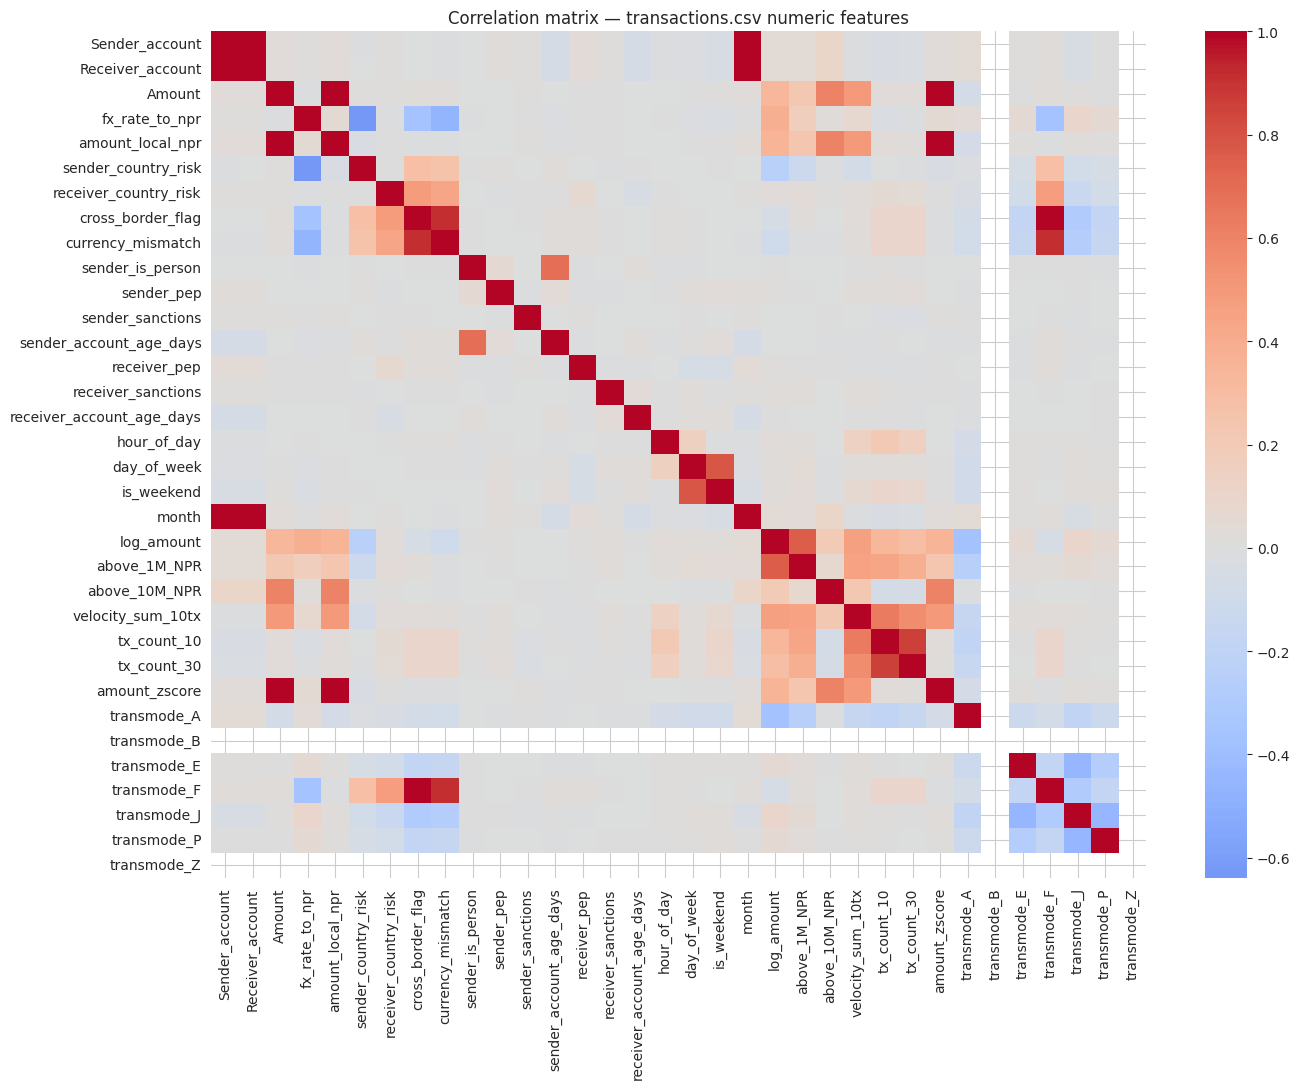

In [17]:
numeric_cols = df_txn.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["row_index"]]

plt.figure(figsize=(14, 11))
corr = df_txn[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix — transactions.csv numeric features")
plt.tight_layout()
plt.show()


In [23]:
df_merged = None

if df_merged is None:
    check_cols = [c for c in [SENDER_COL, RECEIVER_COL, DATE_COL, TIME_COL] if c in df_features.columns]
    if len(df_txn) == len(df_features) and check_cols:
        a = df_txn[check_cols].reset_index(drop=True)
        b = df_features[check_cols].reset_index(drop=True)
        match_rate = (a == b).all(axis=1).mean()
        if match_rate > 0.999:
            df_merged = df_txn.reset_index(drop=True).copy()
            df_merged[LABEL_COL] = df_features[LABEL_COL].reset_index(drop=True).values


print()
print(f"Rows in df_merged: {len(df_merged):,}  (must equal transactions.csv's {len(df_txn):,})")
assert len(df_merged) == len(df_txn), "STOP — row count mismatch. Do not trust df_merged."
print("PASSED. Row counts match exactly — safe to proceed.")
print(f"Rows with a label: {df_merged[LABEL_COL].notnull().sum():,}")
print(f"Positive rate among labeled rows: {df_merged[LABEL_COL].mean():.3%}")



Rows in df_merged: 100,222  (must equal transactions.csv's 100,222)
PASSED. Row counts match exactly — safe to proceed.
Rows with a label: 100,222
Positive rate among labeled rows: 0.335%


### Sender, receiver, and `is_suspicious_tx` — the relationship in detail



In [24]:
sender_stats = df_merged.groupby(SENDER_COL).agg(
    total_sent=(LABEL_COL, "size"),
    suspicious_sent=(LABEL_COL, "sum"),
).reset_index()
sender_stats["suspicious_rate_sent"] = sender_stats["suspicious_sent"] / sender_stats["total_sent"]

receiver_stats = df_merged.groupby(RECEIVER_COL).agg(
    total_received=(LABEL_COL, "size"),
    suspicious_received=(LABEL_COL, "sum"),
).reset_index()
receiver_stats["suspicious_rate_received"] = receiver_stats["suspicious_received"] / receiver_stats["total_received"]

print(f"Accounts that sent >=1 transaction: {len(sender_stats):,}  |  sent >=1 SUSPICIOUS transaction: {(sender_stats['suspicious_sent']>0).sum():,}")
print(f"Accounts that received >=1 transaction: {len(receiver_stats):,}  |  received >=1 SUSPICIOUS transaction: {(receiver_stats['suspicious_received']>0).sum():,}")


Accounts that sent >=1 transaction: 22,310  |  sent >=1 SUSPICIOUS transaction: 237
Accounts that received >=1 transaction: 46,586  |  received >=1 SUSPICIOUS transaction: 223


In [25]:
print("Top 15 sender accounts by NUMBER of suspicious transactions sent:")
display(sender_stats.sort_values("suspicious_sent", ascending=False).head(15))

print("\nTop 15 receiver accounts by NUMBER of suspicious transactions received:")
display(receiver_stats.sort_values("suspicious_received", ascending=False).head(15))


Top 15 sender accounts by NUMBER of suspicious transactions sent:


,Sender_account,total_sent,suspicious_sent,suspicious_rate_sent
22232,900000000085,12,12,1.000
22165,900000000012,10,10,1.000
22177,900000000025,10,10,1.000
22199,900000000049,10,10,1.000
22211,900000000062,9,9,1.000
22155,900000000001,8,8,1.000
22222,900000000074,8,8,1.000
22189,900000000038,8,8,1.000
5185,2369776263,8,5,0.625
21444,9678311627,4,4,1.000



Top 15 receiver accounts by NUMBER of suspicious transactions received:


,Receiver_account,total_received,suspicious_received,suspicious_rate_received
46508,900000000086,12,12,1.0
46453,900000000026,10,10,1.0
46475,900000000050,10,10,1.0
46441,900000000013,10,10,1.0
46487,900000000063,9,9,1.0
46431,900000000002,8,8,1.0
46465,900000000039,8,8,1.0
46498,900000000075,8,8,1.0
19799,4316483340,4,4,1.0
13648,2987279234,4,4,1.0


In [26]:
# Rate-based view, with a minimum-volume filter so a single lucky/unlucky transaction
# doesn't dominate the ranking purely by chance.
MIN_TXNS = 3

print(f"Top 15 senders by suspicious RATE (min {MIN_TXNS} transactions sent):")
display(sender_stats[sender_stats["total_sent"] >= MIN_TXNS]
        .sort_values("suspicious_rate_sent", ascending=False).head(15))

print(f"\nTop 15 receivers by suspicious RATE (min {MIN_TXNS} transactions received):")
display(receiver_stats[receiver_stats["total_received"] >= MIN_TXNS]
        .sort_values("suspicious_rate_received", ascending=False).head(15))


Top 15 senders by suspicious RATE (min 3 transactions sent):


,Sender_account,total_sent,suspicious_sent,suspicious_rate_sent
22232,900000000085,12,12,1.000000
21444,9678311627,4,4,1.000000
13979,6340007440,4,4,1.000000
22222,900000000074,8,8,1.000000
22211,900000000062,9,9,1.000000
22199,900000000049,10,10,1.000000
22189,900000000038,8,8,1.000000
22177,900000000025,10,10,1.000000
22155,900000000001,8,8,1.000000
12862,5825377846,3,3,1.000000



Top 15 receivers by suspicious RATE (min 3 transactions received):


,Receiver_account,total_received,suspicious_received,suspicious_rate_received
25495,5557620276,4,4,1.0
44366,9553458659,3,3,1.0
1178,250142155,3,3,1.0
19799,4316483340,4,4,1.0
11612,2531548770,3,3,1.0
36772,7951108994,3,3,1.0
38018,8202539172,3,3,1.0
21095,4604350890,4,4,1.0
20599,4497771501,3,3,1.0
6406,1407059664,3,3,1.0


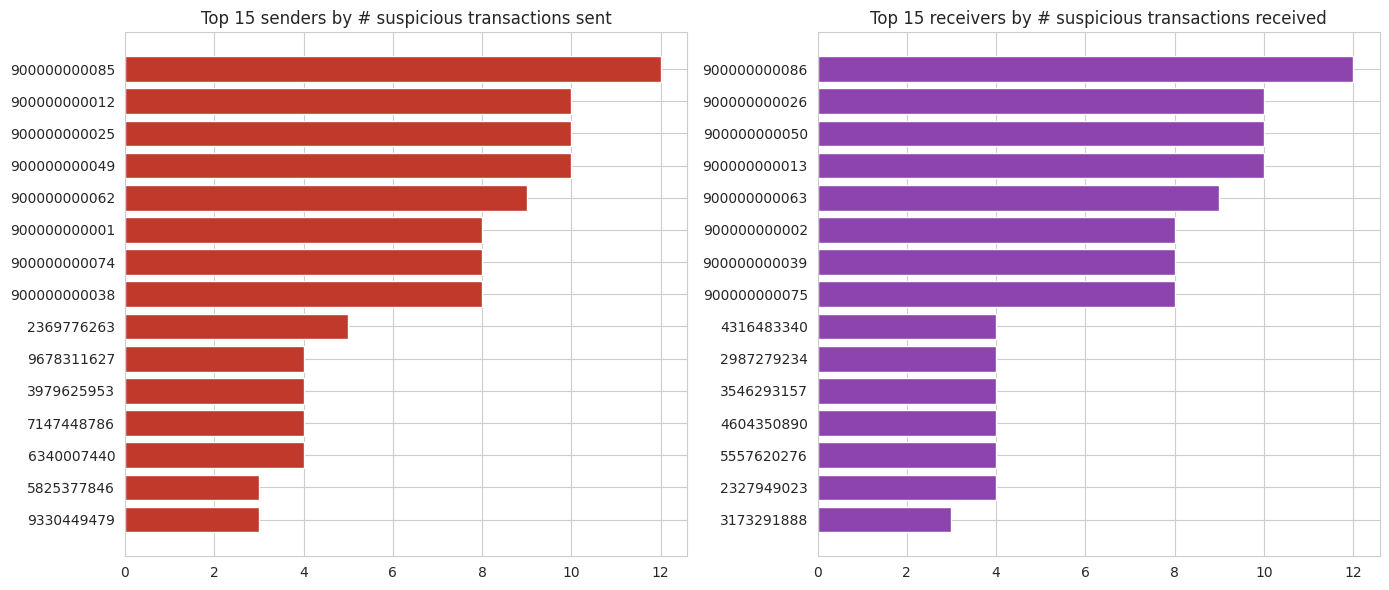

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_senders = sender_stats.sort_values("suspicious_sent", ascending=False).head(15)
axes[0].barh(top_senders[SENDER_COL].astype(str), top_senders["suspicious_sent"], color="#c0392b")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 senders by # suspicious transactions sent")

top_receivers = receiver_stats.sort_values("suspicious_received", ascending=False).head(15)
axes[1].barh(top_receivers[RECEIVER_COL].astype(str), top_receivers["suspicious_received"], color="#8e44ad")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 receivers by # suspicious transactions received")

plt.tight_layout()
plt.show()


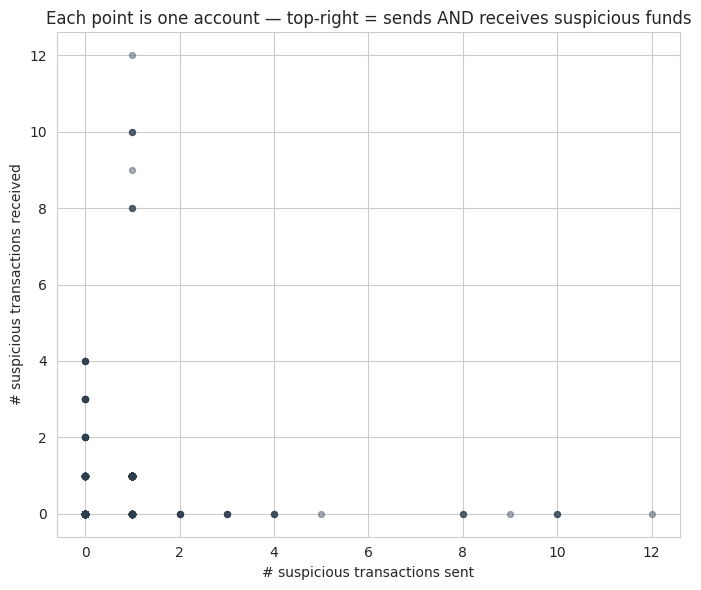

Accounts that BOTH sent and received at least one suspicious transaction: 141


,account,suspicious_sent,suspicious_received,total_suspicious_touch
65253,900000000086,1.0,12.0,13.0
65193,900000000026,1.0,10.0,11.0
65217,900000000050,1.0,10.0,11.0
65180,900000000013,1.0,10.0,11.0
65230,900000000063,1.0,9.0,10.0
65169,900000000002,1.0,8.0,9.0
65206,900000000039,1.0,8.0,9.0
65242,900000000075,1.0,8.0,9.0
65173,900000000006,1.0,1.0,2.0
65172,900000000005,1.0,1.0,2.0


In [29]:
# "Mule" / pass-through check: accounts that are BOTH a high-risk sender AND receiver
s = sender_stats.rename(columns={SENDER_COL: "account"})
r = receiver_stats.rename(columns={RECEIVER_COL: "account"})
combined = s.merge(r, on="account", how="outer").fillna(0)
combined["total_suspicious_touch"] = combined["suspicious_sent"] + combined["suspicious_received"]

plt.figure(figsize=(7, 6))
plt.scatter(combined["suspicious_sent"], combined["suspicious_received"], alpha=0.4, s=18, color="#2c3e50")
plt.xlabel("# suspicious transactions sent")
plt.ylabel("# suspicious transactions received")
plt.title("Each point is one account — top-right = sends AND receives suspicious funds")
plt.tight_layout()
plt.show()

both_sides = combined[(combined["suspicious_sent"] > 0) & (combined["suspicious_received"] > 0)]
print(f"Accounts that BOTH sent and received at least one suspicious transaction: {len(both_sides):,}")
display(both_sides.sort_values("total_suspicious_touch", ascending=False).head(15)[
    ["account", "suspicious_sent", "suspicious_received", "total_suspicious_touch"]
])


In [30]:
# Pair-level preview: this table IS next phase's highest-risk graph edges
pair_stats = df_merged.groupby([SENDER_COL, RECEIVER_COL]).agg(
    total_txns=(LABEL_COL, "size"),
    suspicious_txns=(LABEL_COL, "sum"),
    total_amount=(AMOUNT_COL, "sum"),
).reset_index()
pair_stats["suspicious_rate"] = pair_stats["suspicious_txns"] / pair_stats["total_txns"]

print(f"Unique sender-receiver pairs: {len(pair_stats):,}")
print(f"Pairs with >=1 suspicious transaction: {(pair_stats['suspicious_txns']>0).sum():,}")
print()
print("Top 15 sender-receiver pairs by # suspicious transactions:")
display(pair_stats.sort_values("suspicious_txns", ascending=False).head(15))

Unique sender-receiver pairs: 50,586
Pairs with >=1 suspicious transaction: 320

Top 15 sender-receiver pairs by # suspicious transactions:


,Sender_account,Receiver_account,total_txns,suspicious_txns,total_amount,suspicious_rate
35806,7147448786,5557620276,4,4,107472.69,1.0
31798,6340007440,4316483340,4,4,131984.12,1.0
48706,9678311627,4604350890,4,4,142523.68,1.0
31986,6381030298,9553458659,3,3,41629.73,1.0
46811,9330449479,1407059664,3,3,48070.69,1.0
29224,5825377846,250142155,3,3,85461.97,1.0
26497,5262095561,927895922,2,2,1566923.44,1.0
50369,900000000001,900000000009,1,1,1968109.57,1.0
50371,900000000001,900000000011,1,1,1972950.57,1.0
50372,900000000002,900000000003,1,1,21078765.11,1.0


---
## EDA Requirement 6 — Summary of key insights

In [33]:
insight_lines = [
    f"- Confirmed scale: {df_accounts.shape[0]:,} accounts, {df_txn.shape[0]:,} transactions.",
    f"- Amount ({AMOUNT_COL}) is right-skewed: mean is "
    f"{df_txn[AMOUNT_COL].mean()/max(df_txn[AMOUNT_COL].median(),1):.1f}x the median.",
    f"- Referential integrity is clean: 0 orphan accounts.",
    f"- Label `{LABEL_COL}` is transaction-level and heavily imbalanced "
    f"({df_merged[LABEL_COL].mean():.3%} positive).",
    f"- {(sender_stats['suspicious_sent']>0).sum():,} accounts sent >=1 suspicious transaction, "
    f"{(receiver_stats['suspicious_received']>0).sum():,} received >=1, and "
    f"{len(both_sides):,} did both — these overlap accounts are early mule candidates.",
]

worst_pct = max((v["missing_pct"].max() for v in missing_summary.values() if len(v)), default=0)
insight_lines.append(f"- Worst single-column missingness observed: {worst_pct:.1f}%.")

print("INSIGHTS:\n")
for line in insight_lines:
    print(line)


INSIGHTS:

- Confirmed scale: 65,339 accounts, 100,222 transactions.
- Amount (amount_local_npr) is right-skewed: mean is 1.4x the median.
- Referential integrity is clean: 0 orphan accounts.
- Label `is_suspicious_tx` is transaction-level and heavily imbalanced (0.335% positive).
- 237 accounts sent >=1 suspicious transaction, 223 received >=1, and 141 did both — these overlap accounts are early mule candidates.
- Worst single-column missingness observed: 0.0%.
